<a href="https://colab.research.google.com/github/Sharu-052897/deep-learning/blob/main/MLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Input shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu',
                 input_shape=(X_train.shape[1],)),

    layers.Dense(8, activation='relu'),

    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=15,
    validation_split=0.2
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8854 - loss: 0.2764 - val_accuracy: 0.8750 - val_loss: 0.2809
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8854 - loss: 0.2716 - val_accuracy: 0.8750 - val_loss: 0.2721
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8854 - loss: 0.2666 - val_accuracy: 0.8750 - val_loss: 0.2638
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8958 - loss: 0.2617 - val_accuracy: 0.8750 - val_loss: 0.2587
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8958 - loss: 0.2565 - val_accuracy: 0.9167 - val_loss: 0.2538
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8958 - loss: 0.2519 - val_accuracy: 0.9167 - val_loss: 0.2469
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8958 - loss: 0.2475 - val_accuracy: 0.9167 - val_loss: 0.2427
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8958 - loss: 0.2432 - val_accuracy: 0.9167 - val_loss: 0.2352


In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8667 - loss: 0.2680
Test Loss: 0.26795345544815063
Test Accuracy: 0.8666666746139526


In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print("Actual classes:")
print(y_test[:10])

print("\nPredicted classes:")
print(predicted_classes[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Actual classes:
[0 2 1 1 0 1 0 0 2 1]

Predicted classes:
[0 2 1 1 0 2 0 0 2 1]


In [ ]:
for i in range(10):
    print(
        "Actual:",
        iris.target_names[y_test[i]],
        "| Predicted:",
        iris.target_names[predicted_classes[i]]
    )

Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: virginica
Actual: setosa | Predicted: setosa
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor


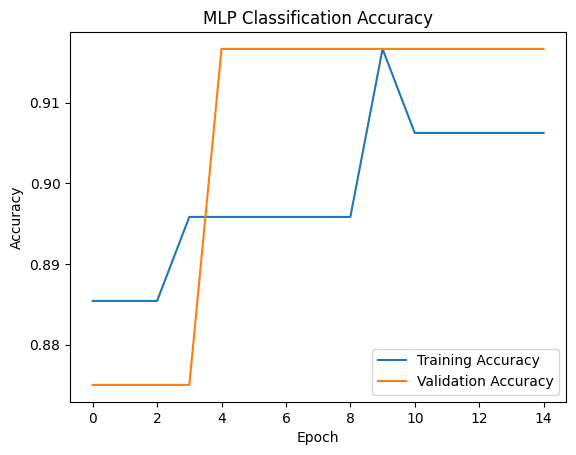

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Classification Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

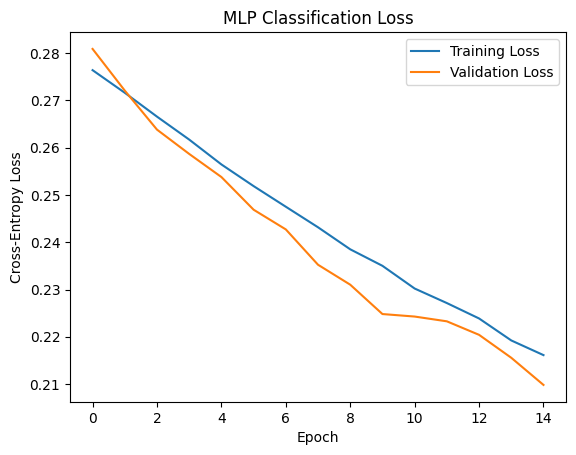

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MLP Classification Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()